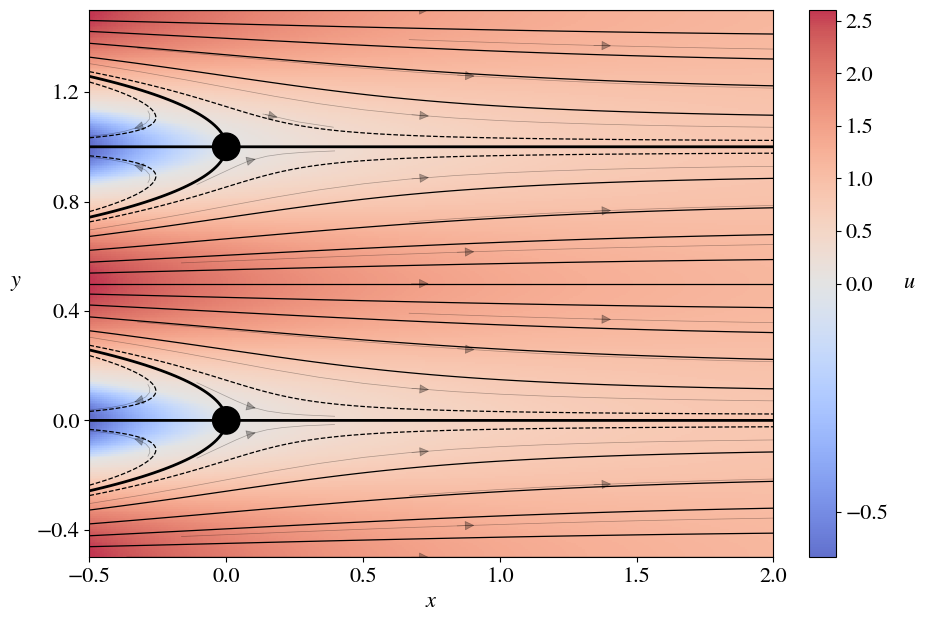

/tmp/ipykernel_7770/2490634147.py:140: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_smooth = cm.get_cmap('coolwarm').copy()


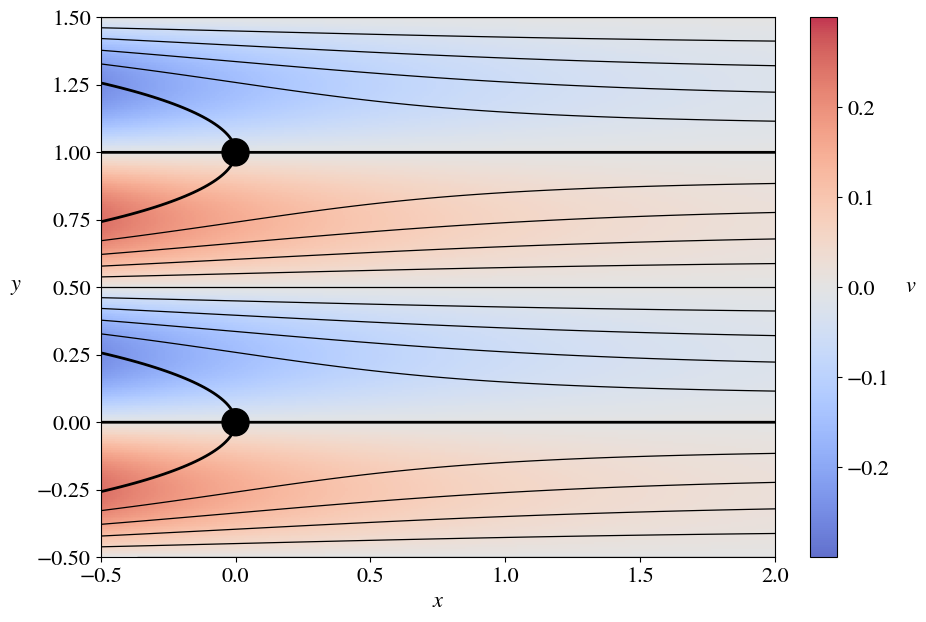

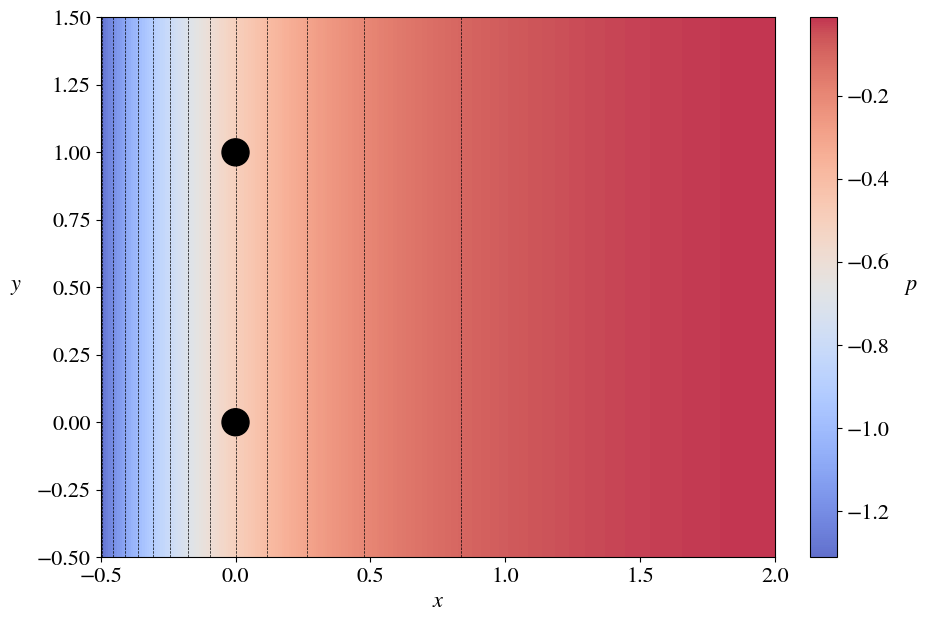

In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm

# Visual setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 16
})

# Kovasznay Parameters
Re = 40.0
kov_lambda = (Re / 2.0) - np.sqrt((Re**2 / 4.0) + 4.0 * np.pi**2)

# Grid
nx, ny = 150, 100
nt = 20 
x = np.linspace(-0.5, 1.5, nx)
y = np.linspace(-0.5, 0.5, ny)
t = np.linspace(0.0, 2.0, nt) 
X_grid, Y_grid = np.meshgrid(x, y)

# Exportation setup (to be use in PINN)
N_points = nx * ny
X_star = np.stack([X_grid.flatten(), Y_grid.flatten()], axis=1)
U_star = np.zeros((N_points, 2, nt))
p_star = np.zeros((N_points, nt))

# Exact velocity and pressure solutions
u_exact = 1.0 - np.exp(kov_lambda * X_grid) * np.cos(2.0 * np.pi * Y_grid)
v_exact = (kov_lambda / (2.0 * np.pi)) * np.exp(kov_lambda * X_grid) * np.sin(2.0 * np.pi * Y_grid)
p_exact = -0.5 * np.exp(2.0 * kov_lambda * X_grid)

# Export file
for i in range(nt):
    U_star[:, 0, i] = u_exact.flatten()
    U_star[:, 1, i] = v_exact.flatten()
    p_star[:, i]    = p_exact.flatten()
output_file = 'kovasznay_data.mat'
sio.savemat(output_file, {
    'X_star': X_star, 
    't': t.reshape(-1, 1),
    'U_star': U_star, 
    'p_star': p_star
})


# Visualization: Velocity u

# Grid
nn_res = 300 
x_vis = np.linspace(-0.5, 2.0, nn_res)
y_vis = np.linspace(-0.5, 1.5, nn_res)
X_vis, Y_vis = np.meshgrid(x_vis, y_vis)

# Exact fields
u_vis = 1.0 - np.exp(kov_lambda * X_vis) * np.cos(2.0 * np.pi * Y_vis)
v_vis = (kov_lambda / (2.0 * np.pi)) * np.exp(kov_lambda * X_vis) * np.sin(2.0 * np.pi * Y_vis)

# Exact psi
psi_vis = Y_vis - (1.0 / (2.0 * np.pi)) * np.exp(kov_lambda * X_vis) * np.sin(2.0 * np.pi * Y_vis)

fig_u, ax_u = plt.subplots(figsize=(10, 6.5))

# Colormap
norm_u = TwoSlopeNorm(vcenter=0, vmin=-0.6, vmax=2.6)
c0 = ax_u.pcolormesh(X_vis, Y_vis, u_vis, cmap='coolwarm', norm=norm_u, shading='auto', alpha=0.8)
cbar = fig_u.colorbar(c0, ax=ax_u, fraction=0.046, pad=0.04)
cbar.set_label(r'$u$', fontsize=16, rotation=0, labelpad=15, va='center')

# Streamlines
ax_u.contour(X_vis, Y_vis, psi_vis, levels=np.arange(-0.6, 1.65, 0.1), colors='black', 
             linewidths=0.9, linestyles='solid', zorder=2)
ax_u.contour(X_vis, Y_vis, psi_vis, levels=[-0.02, 0.02, 0.98, 1.02], colors='black', 
             linewidths=0.9, linestyles='dashed', zorder=2)
ax_u.contour(X_vis, Y_vis, psi_vis, levels=[0.0, 1.0], colors='black', 
             linewidths=2.0, linestyles='solid', zorder=3)

ax_u.streamplot(X_vis, Y_vis, u_vis, v_vis, color=(0, 0, 0, 0.3), 
                density=(0.5, 0.5), linewidth=0.5, arrowsize=1.5, 
                zorder=4)

# Details
wire_radius = 0.05
ax_u.add_patch(patches.Circle((0, 0.0), wire_radius, color='black', zorder=10))
ax_u.add_patch(patches.Circle((0, 1.0), wire_radius, color='black', zorder=10))

# Fomat
ax_u.set_xlabel(r'$x$', fontsize=16)
ax_u.set_ylabel(r'$y$', fontsize=16, rotation=0, labelpad=15, va='center')

ax_u.set_xlim(-0.5, 2.0)
ax_u.set_ylim(-0.5, 1.5)
ax_u.set_aspect('equal')
ax_u.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax_u.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.tight_layout()
fig_u.savefig('Images/Kovasznay_u.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization: Velocity v
fig_v, ax_v = plt.subplots(figsize=(10, 6.5))

# Colormap
norm_v = TwoSlopeNorm(vcenter=0, vmin=-0.3, vmax=0.3)
c1 = ax_v.pcolormesh(X_vis, Y_vis, v_vis, cmap='coolwarm', norm=norm_v, shading='auto', alpha=0.8)
cbar_v = fig_v.colorbar(c1, ax=ax_v, fraction=0.046, pad=0.04)
cbar_v.set_label(r'$v$', fontsize=16, rotation=0, labelpad=15, va='center')

# Streamlines
ax_v.contour(X_vis, Y_vis, psi_vis, levels=np.arange(-0.6, 1.65, 0.1), colors='black', 
             linewidths=0.9, linestyles='solid', zorder=2)
ax_v.contour(X_vis, Y_vis, psi_vis, levels=[0.0, 1.0], colors='black', 
             linewidths=2.0, linestyles='solid', zorder=3)

# Details
ax_v.add_patch(patches.Circle((0, 0.0), wire_radius, color='black', zorder=10))
ax_v.add_patch(patches.Circle((0, 1.0), wire_radius, color='black', zorder=10))

# Format
ax_v.set_xlabel(r'$x$', fontsize=16)
ax_v.set_ylabel(r'$y$', fontsize=16, rotation=0, labelpad=15, va='center')
ax_v.set_xlim(-0.5, 2.0); ax_v.set_ylim(-0.5, 1.5); ax_v.set_aspect('equal')
plt.tight_layout()
fig_v.savefig('Images/Kovasznay_v.png', dpi=300, bbox_inches='tight')

# Visualization: Pressure
p_vis = -0.5 * np.exp(2.0 * kov_lambda * X_vis)

fig_p, ax_p = plt.subplots(figsize=(10, 6.5))

# Colormap
cmap_smooth = cm.get_cmap('coolwarm').copy()
c2 = ax_p.pcolormesh(X_vis, Y_vis, p_vis, cmap=cmap_smooth, shading='auto', alpha=0.8)
cbar_p = fig_p.colorbar(c2, ax=ax_p, fraction=0.046, pad=0.04)
cbar_p.set_label(r'$p$', fontsize=16, rotation=0, labelpad=15, va='center')

# Isobar
ax_p.contour(X_vis, Y_vis, p_vis, levels=15, colors='black', linewidths=0.5, linestyles='dashed', zorder=2)

# Details
ax_p.add_patch(patches.Circle((0, 0.0), wire_radius, color='black', zorder=10))
ax_p.add_patch(patches.Circle((0, 1.0), wire_radius, color='black', zorder=10))

# Format
ax_p.set_xlabel(r'$x$', fontsize=16)
ax_p.set_ylabel(r'$y$', fontsize=16, rotation=0, labelpad=15, va='center')
ax_p.set_xlim(-0.5, 2.0); ax_p.set_ylim(-0.5, 1.5); ax_p.set_aspect('equal')
plt.tight_layout()
fig_p.savefig('Images/Kovasznay_p.png', dpi=300, bbox_inches='tight')
plt.show()